In [1]:
# PHASE 1: ENVIRONMENT & REPRODUCIBILITY

# Step 1: Install required libraries
!pip install datasets transformers peft xgboost evaluate gradio accelerate spacy nltk seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [2]:
# Step 2: Download spaCy English model
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 83.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# Step 3: Set seed for reproducibility

import random
import numpy as np
import torch

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensures deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
# Step 4: Multi-run setup (for Mean ± Std reporting)

seeds = [42, 7]

In [5]:
# Step 5: Device setup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Explicit CPU reference for classical models
cpu_device = torch.device("cpu")

Using device: cuda


In [6]:
# Step 6: Create required directories

import os

DIRS = ["data", "models", "adapters", "results"]

for d in DIRS:
    os.makedirs(d, exist_ok=True)

In [7]:
# Step 7: Initialize logging file

import pandas as pd
import os

log_path = "results/log.csv"

# Create only if it doesn't exist
if not os.path.exists(log_path):
    log_df = pd.DataFrame(columns=["Seed", "Model", "Variety", "Task", "Macro-F1"])
    log_df.to_csv(log_path, index=False)

print("Logging file ready at:", log_path)

Logging file ready at: results/log.csv


In [8]:
# Step 8: Load BESSTIE dataset (en-UK, en-AU, en-IN)

from datasets import load_dataset

dataset = load_dataset("surrey-nlp/BESSTIE-CW-26")

# Apply filtering per split (VERY IMPORTANT)

uk_data = {
    split: dataset[split].filter(lambda x: x["variety"] == "en-UK")
    for split in dataset.keys()
}

au_data = {
    split: dataset[split].filter(lambda x: x["variety"] == "en-AU")
    for split in dataset.keys()
}

in_data = {
    split: dataset[split].filter(lambda x: x["variety"] == "en-IN")
    for split in dataset.keys()
}

# quick check
print(uk_data["train"])
print(au_data["train"])
print(in_data["train"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

...

Filter:   0%|          | 0/2183 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3747 [00:00<?, ? examples/s]

Filter:   0%|          | 0/313 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2183 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
    num_rows: 1203
})
Dataset({
    features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
    num_rows: 1145
})
Dataset({
    features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
    num_rows: 1399
})


In [9]:
# =========================================
# STEP 9–10: SAFE DATA + LABEL PIPELINE
# =========================================

import pandas as pd

# -----------------------------
# Step 9: Create DataFrames
# -----------------------------
def split_to_df(data):
    return (
        pd.DataFrame(data["train"]),
        pd.DataFrame(data["validation"]),
        pd.DataFrame(data["test"])
    )

uk_train, uk_val, uk_test = split_to_df(uk_data)
au_train, au_val, au_test = split_to_df(au_data)
in_train, in_val, in_test = split_to_df(in_data)

print("Datasets created ✅")
print("UK shape:", uk_train.shape)


# -----------------------------
# Step 10: SAFE LABEL CREATION
# -----------------------------

def create_label(df):
    cols = df.columns

    # Case 1: sarcasm column exists
    if "sarcasm" in cols:
        df["label"] = df["sarcasm"].map({
            "NotSarcastic": 0,
            "Sarcastic": 1
        })

    # Case 2: sentiment column exists
    elif "sentiment" in cols:
        df["label"] = df["sentiment"].map({
            "Negative": 0,
            "Positive": 1
        })

    # Case 3: already numeric label exists
    elif "label" in cols:
        df["label"] = df["label"]

    # Case 4: fallback auto-detect (last column)
    else:
        df["label"] = df.iloc[:, -1]

    return df


# Apply safely
uk_train = create_label(uk_train)
uk_val   = create_label(uk_val)
uk_test  = create_label(uk_test)

au_train = create_label(au_train)
au_val   = create_label(au_val)
au_test  = create_label(au_test)

in_train = create_label(in_train)
in_val   = create_label(in_val)
in_test  = create_label(in_test)

print("Label column created successfully ✅")

# -----------------------------
# DEBUG CHECK (IMPORTANT)
# -----------------------------
print("\nColumns:", uk_train.columns)
print("\nLabel distribution:")
print(uk_train["label"].value_counts())

Datasets created ✅
UK shape: (1203, 5)
Label column created successfully ✅

Columns: Index(['text', 'variety', 'source', 'Sentiment', 'Sarcasm', 'label'], dtype='object')

Label distribution:
label
0.0    1111
1.0      92
Name: count, dtype: int64


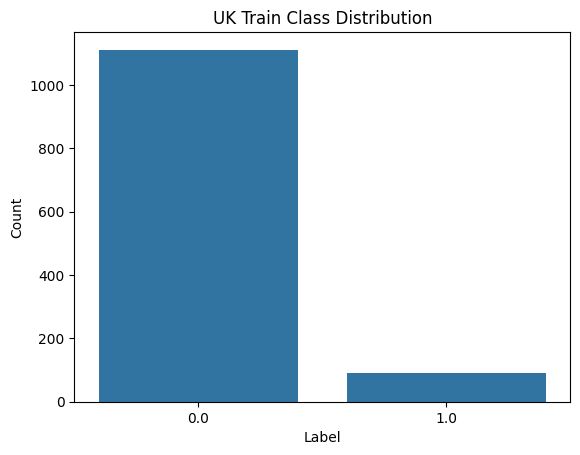

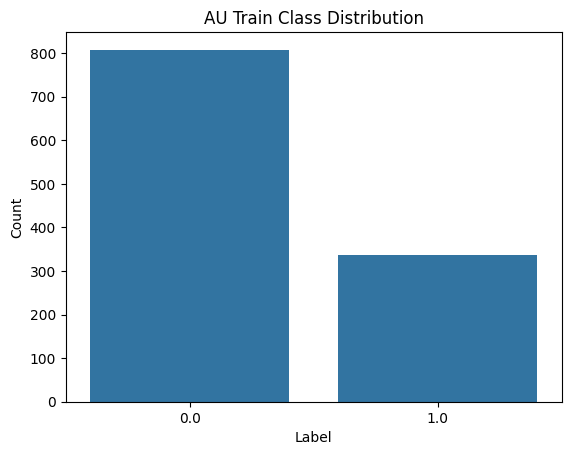

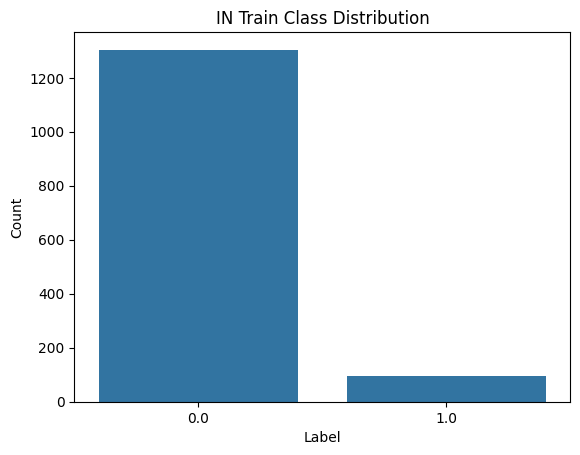

Unique labels in UK: [0. 1.]
Unique labels in AU: [1. 0.]
Unique labels in IN: [0. 1.]

UK Train Class Distribution (%)
label
0.0    92.352452
1.0     7.647548
Name: proportion, dtype: float64

AU Train Class Distribution (%)
label
0.0    70.567686
1.0    29.432314
Name: proportion, dtype: float64

IN Train Class Distribution (%)
label
0.0    93.209435
1.0     6.790565
Name: proportion, dtype: float64


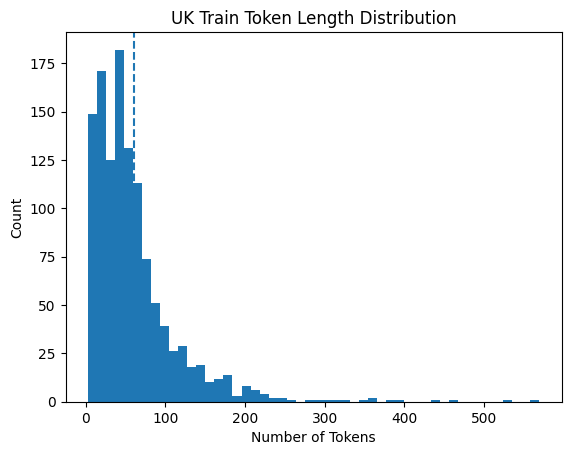

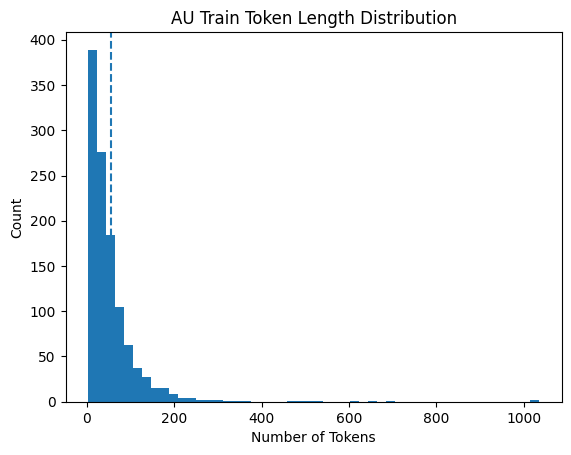

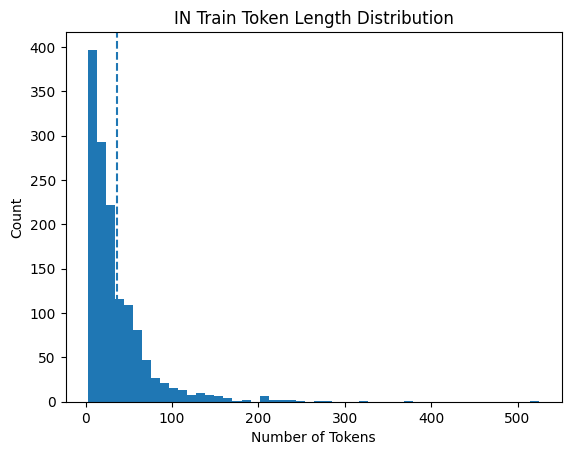


UK Train Length Stats
Mean: 60.87364921030756
Max : 569
Min : 3

AU Train Length Stats
Mean: 55.16419213973799
Max : 1035
Min : 3

IN Train Length Stats
Mean: 36.17726947819871
Max : 525
Min : 3
UK Train 95th percentile: 164.0
AU Train 95th percentile: 152.5999999999999
IN Train 95th percentile: 107.09999999999991


In [10]:
# Step 11: Class imbalance analysis (final clean)

import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_distribution(df, name):
    sns.countplot(x="label", data=df)
    plt.title(f"{name} Class Distribution")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()

plot_class_distribution(uk_train, "UK Train")
plot_class_distribution(au_train, "AU Train")
plot_class_distribution(in_train, "IN Train")

# Step 11(a): Verify label column correctness

print("Unique labels in UK:", uk_train["label"].unique())
print("Unique labels in AU:", au_train["label"].unique())
print("Unique labels in IN:", in_train["label"].unique())
# Step 11(b): Class percentage distribution

def print_class_ratio(df, name):
    counts = df["label"].value_counts(normalize=True) * 100
    print(f"\n{name} Class Distribution (%)")
    print(counts)

print_class_ratio(uk_train, "UK Train")
print_class_ratio(au_train, "AU Train")
print_class_ratio(in_train, "IN Train")

# Step 12: Length analysis (improved)

def plot_length_distribution(df, name):
    lengths = df["text"].apply(lambda x: len(x.split()))

    plt.figure()
    plt.hist(lengths, bins=50)
    plt.axvline(lengths.mean(), linestyle='--')  # optional but nice
    plt.title(f"{name} Token Length Distribution")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Count")
    plt.show()

plot_length_distribution(uk_train, "UK Train")
plot_length_distribution(au_train, "AU Train")
plot_length_distribution(in_train, "IN Train")

# Based on observation
MAX_LENGTH = 128
# Step 12(a): Token length statistics

def length_stats(df, name):
    lengths = df["text"].apply(lambda x: len(x.split()))
    print(f"\n{name} Length Stats")
    print("Mean:", lengths.mean())
    print("Max :", lengths.max())
    print("Min :", lengths.min())

length_stats(uk_train, "UK Train")
length_stats(au_train, "AU Train")
length_stats(in_train, "IN Train")

# Step 12(b): 95th percentile length

def length_percentile(df, name):
    lengths = df["text"].apply(lambda x: len(x.split()))
    print(f"{name} 95th percentile:", np.percentile(lengths, 95))

length_percentile(uk_train, "UK Train")
length_percentile(au_train, "AU Train")
length_percentile(in_train, "IN Train")

In [11]:
# Step 13: Vocabulary extraction using spaCy (nouns + adjectives)

import spacy

# Load once (optimized)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def get_vocab(df):
    vocab = set()

    # Use nlp.pipe for speed
    for doc in nlp.pipe(df["text"], batch_size=64):
        for token in doc:
            if token.pos_ in ["NOUN", "ADJ"]:
                vocab.add(token.lemma_.lower())

    return vocab

# Extract vocabularies
uk_vocab = get_vocab(uk_train)
au_vocab = get_vocab(au_train)
in_vocab = get_vocab(in_train)

# quick check
print("Vocab sizes:", len(uk_vocab), len(au_vocab), len(in_vocab))


# Step 14: Jaccard similarity

def jaccard_similarity(set1, set2):
    return len(set1.intersection(set2)) / len(set1.union(set2))

uk_au = jaccard_similarity(uk_vocab, au_vocab)
uk_in = jaccard_similarity(uk_vocab, in_vocab)
au_in = jaccard_similarity(au_vocab, in_vocab)

# rounded output (clean)
print("UK vs AU:", round(uk_au, 3))
print("UK vs IN:", round(uk_in, 3))
print("AU vs IN:", round(au_in, 3))


# Step 14(b): Identify most similar pair

similarities = {
    "UK-AU": uk_au,
    "UK-IN": uk_in,
    "AU-IN": au_in
}

closest = max(similarities, key=similarities.get)
print("Most similar dialects:", closest)


# Step 14(c): Safety check
print("Sample UK vocab:", list(uk_vocab)[:10])

Vocab sizes: 3953 4212 3670
UK vs AU: 0.373
UK vs IN: 0.315
AU vs IN: 0.315
Most similar dialects: UK-AU
Sample UK vocab: ['pea', 'neat', 'traditional', 'spanish', 'colour', 'asylum', 'stool', 'homeowner', 'degree', 'pasty']


In [12]:
# Step 15: Linguistic distance summary

# Collect similarity scores
scores = {
    "UK-AU": uk_au,
    "UK-IN": uk_in,
    "AU-IN": au_in
}

# Most similar pair
most_similar = max(scores, key=scores.get)

# Least similar pair
least_similar = min(scores, key=scores.get)

# Print raw scores
print("Vocabulary Overlap Scores:")
for pair, score in scores.items():
    print(f"{pair}: {round(score, 3)}")

print("\nMost similar varieties:", most_similar)
print("Least similar varieties:", least_similar)

# Sorted view (best → worst)
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

print("\nSorted Similarities:")
for pair, score in sorted_scores:
    print(f"{pair}: {round(score, 3)}")

# Summary (report-ready)
print("\nSummary:")
print(f"{most_similar} shows the highest lexical overlap, indicating closer linguistic similarity.")
print(f"{least_similar} shows the lowest overlap, indicating greater linguistic divergence.")
print("This suggests that regional vocabulary, slang, and usage patterns influence linguistic distance across varieties.")

Vocabulary Overlap Scores:
UK-AU: 0.373
UK-IN: 0.315
AU-IN: 0.315

Most similar varieties: UK-AU
Least similar varieties: AU-IN

Sorted Similarities:
UK-AU: 0.373
UK-IN: 0.315
AU-IN: 0.315

Summary:
UK-AU shows the highest lexical overlap, indicating closer linguistic similarity.
AU-IN shows the lowest overlap, indicating greater linguistic divergence.
This suggests that regional vocabulary, slang, and usage patterns influence linguistic distance across varieties.


In [13]:
# PHASE 3: ADVANCED PREPROCESSING

# Step 16: Text cleaning (remove urls, handles, html)

import re

def clean_text(text):
    text = text.lower()  # added for consistency
    text = re.sub(r"http\S+|www\S+", "", text)   # remove urls
    text = re.sub(r"@\w+", "", text)             # remove user handles
    text = re.sub(r"<.*?>", "", text)            # remove html tags
    text = re.sub(r"[^a-zA-Z0-9\s!?]", "", text) # keep ! and ? for sarcasm
    return text.strip()


# Step 16(a): Apply cleaning to all datasets

def apply_cleaning(df):
    df["clean_text"] = df["text"].apply(clean_text)
    return df

uk_train = apply_cleaning(uk_train)
uk_val   = apply_cleaning(uk_val)
uk_test  = apply_cleaning(uk_test)

au_train = apply_cleaning(au_train)
au_val   = apply_cleaning(au_val)
au_test  = apply_cleaning(au_test)

in_train = apply_cleaning(in_train)
in_val   = apply_cleaning(in_val)
in_test  = apply_cleaning(in_test)


# Step 16(b): Verify cleaning

print("\nBefore Cleaning:")
print(uk_train["text"].iloc[0])

print("\nAfter Cleaning:")
print(uk_train["clean_text"].iloc[0])


# Step 17: spaCy pipeline (lightweight)

import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


# Step 17(a): Optional preview of spaCy processing

doc = nlp(uk_train["clean_text"].iloc[0])
print("\nSample Tokens + Lemmas:")
for token in doc[:10]:
    print(token.text, "->", token.lemma_)


Before Cleaning:
I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.

After Cleaning:
im a member of the green party but ill be voting lib dem as its so tight here between lib dem and tory i cannot contemplate our useless tit of a tory mp being reelected ill use the swap my vote website so someone somewhere can vote green for me

Sample Tokens + Lemmas:
i -> I
m -> m
a -> a
member -> member
of -> of
the -> the
green -> green
party -> party
but -> but
ill -> ill


In [14]:
# Step 18: Lemmatization using spaCy (optimized)

def lemmatize_texts(texts):
    lemmatized = []

    for doc in nlp.pipe(texts, batch_size=64):
        tokens = [token.lemma_.lower() for token in doc]
        lemmatized.append(" ".join(tokens))

    return lemmatized


# Step 18(a): Apply lemmatization

def apply_lemmatization(df):
    df["lemma_text"] = lemmatize_texts(df["clean_text"])
    return df

uk_train = apply_lemmatization(uk_train)
uk_val   = apply_lemmatization(uk_val)
uk_test  = apply_lemmatization(uk_test)

au_train = apply_lemmatization(au_train)
au_val   = apply_lemmatization(au_val)
au_test  = apply_lemmatization(au_test)

in_train = apply_lemmatization(in_train)
in_val   = apply_lemmatization(in_val)
in_test  = apply_lemmatization(in_test)


# Step 19: Stopword removal (NLTK)

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Step 19(a): Sarcasm-aware stopword strategy

irony_words = {"just", "so", "totally", "really", "very"}  # keep these


def remove_stopwords(text):
    tokens = text.split()
    tokens = [t for t in tokens if (t not in stop_words or t in irony_words)]
    return " ".join(tokens)


# Step 19(b): Apply stopword removal

def apply_stopword_removal(df):
    df["final_text"] = df["lemma_text"].apply(remove_stopwords)
    return df

uk_train = apply_stopword_removal(uk_train)
uk_val   = apply_stopword_removal(uk_val)
uk_test  = apply_stopword_removal(uk_test)

au_train = apply_stopword_removal(au_train)
au_val   = apply_stopword_removal(au_val)
au_test  = apply_stopword_removal(au_test)

in_train = apply_stopword_removal(in_train)
in_val   = apply_stopword_removal(in_val)
in_test  = apply_stopword_removal(in_test)


# Step 19(c): Debug check

print("\nOriginal:", uk_train["text"].iloc[0])
print("\nClean:", uk_train["clean_text"].iloc[0])
print("\nLemma:", uk_train["lemma_text"].iloc[0])
print("\nFinal:", uk_train["final_text"].iloc[0])


Original: I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.

Clean: im a member of the green party but ill be voting lib dem as its so tight here between lib dem and tory i cannot contemplate our useless tit of a tory mp being reelected ill use the swap my vote website so someone somewhere can vote green for me

Lemma: i m a member of the green party but ill be vote lib dem as its so tight here between lib dem and tory i can not contemplate our useless tit of a tory mp be reelect ill use the swap my vote website so someone somewhere can vote green for i

Final: member green party ill vote lib dem so tight lib dem tory contemplate useless tit tory mp reelect ill use swap vote website so someone somewhere vote green


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
# Step 20: Stopword strategy for sarcasm (keep irony markers)

# reuse stop_words from previous step

irony_words = {"just", "so", "totally", "really", "very"}

def remove_stopwords_sarcasm(text):
    tokens = text.split()
    tokens = [t for t in tokens if (t not in stop_words or t in irony_words)]
    return " ".join(tokens)


# Step 20(a): Apply sarcasm-aware stopword removal

def apply_stopword_sarcasm(df):
    df["sarcasm_text"] = df["lemma_text"].apply(remove_stopwords_sarcasm)
    return df

uk_train = apply_stopword_sarcasm(uk_train)
uk_val   = apply_stopword_sarcasm(uk_val)
uk_test  = apply_stopword_sarcasm(uk_test)

au_train = apply_stopword_sarcasm(au_train)
au_val   = apply_stopword_sarcasm(au_val)
au_test  = apply_stopword_sarcasm(au_test)

in_train = apply_stopword_sarcasm(in_train)
in_val   = apply_stopword_sarcasm(in_val)
in_test  = apply_stopword_sarcasm(in_test)


# Step 21: Punctuation preservation (!, ?)

import re

def keep_punctuation(text):
    # keep only words, spaces, ! and ?
    text = re.sub(r"[^\w\s!?]", "", text)
    return text


# Step 21(a): Apply punctuation preservation

def apply_punctuation(df):
    df["sarcasm_text"] = df["sarcasm_text"].apply(keep_punctuation)
    return df

uk_train = apply_punctuation(uk_train)
uk_val   = apply_punctuation(uk_val)
uk_test  = apply_punctuation(uk_test)

au_train = apply_punctuation(au_train)
au_val   = apply_punctuation(au_val)
au_test  = apply_punctuation(au_test)

in_train = apply_punctuation(in_train)
in_val   = apply_punctuation(in_val)
in_test  = apply_punctuation(in_test)


# Step 21(b): Debug check

print("\nOriginal:", uk_train["text"].iloc[0])
print("\nLemma:", uk_train["lemma_text"].iloc[0])
print("\nSarcasm Text:", uk_train["sarcasm_text"].iloc[0])


Original: I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.

Lemma: i m a member of the green party but ill be vote lib dem as its so tight here between lib dem and tory i can not contemplate our useless tit of a tory mp be reelect ill use the swap my vote website so someone somewhere can vote green for i

Sarcasm Text: member green party ill vote lib dem so tight lib dem tory contemplate useless tit tory mp reelect ill use swap vote website so someone somewhere vote green


In [16]:
# Step 22: Initialize TF-IDF (bi-grams)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000
)


# Step 23: Fit only on training data (ZERO DATA LEAKAGE)

# 👉 For SENTIMENT task → use final_text
X_train_uk = vectorizer.fit_transform(uk_train["final_text"])
y_train_uk = uk_train["label"]

# quick check
print("UK Vocab size:", len(vectorizer.vocabulary_))
print("Feature shape:", X_train_uk.shape)

UK Vocab size: 10000
Feature shape: (1203, 10000)


In [17]:
# DO NOT FIT AGAIN

X_val_uk = vectorizer.transform(uk_val["final_text"])
y_val_uk = uk_val["label"]

X_test_uk = vectorizer.transform(uk_test["final_text"])
y_test_uk = uk_test["label"]

In [18]:
# Separate vectorizer (recommended)

vectorizer_sarcasm = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000
)

X_train_uk_sarc = vectorizer_sarcasm.fit_transform(uk_train["sarcasm_text"])
X_val_uk_sarc   = vectorizer_sarcasm.transform(uk_val["sarcasm_text"])
X_test_uk_sarc  = vectorizer_sarcasm.transform(uk_test["sarcasm_text"])

y_train_uk_sarc = uk_train["label"]
y_val_uk_sarc   = uk_val["label"]
y_test_uk_sarc  = uk_test["label"]

In [19]:
# Step 24: Transform val/test using fitted TF-IDF (SENTIMENT)

# IMPORTANT: use final_text (NOT text)

X_train_uk = vectorizer.transform(uk_train["final_text"])
X_val_uk   = vectorizer.transform(uk_val["final_text"])
X_test_uk  = vectorizer.transform(uk_test["final_text"])

X_train_au = vectorizer.transform(au_train["final_text"])
X_val_au   = vectorizer.transform(au_val["final_text"])
X_test_au  = vectorizer.transform(au_test["final_text"])

X_train_in = vectorizer.transform(in_train["final_text"])
X_val_in   = vectorizer.transform(in_val["final_text"])
X_test_in  = vectorizer.transform(in_test["final_text"])

# TF-IDF for sarcasm (separate vectorizer)

vectorizer_sarc = TfidfVectorizer(ngram_range=(1,2), max_features=10000)

X_train_uk_sarc = vectorizer_sarc.fit_transform(uk_train["sarcasm_text"])
X_val_uk_sarc   = vectorizer_sarc.transform(uk_val["sarcasm_text"])
X_test_uk_sarc  = vectorizer_sarc.transform(uk_test["sarcasm_text"])

X_train_au_sarc = vectorizer_sarc.transform(au_train["sarcasm_text"])
X_val_au_sarc   = vectorizer_sarc.transform(au_val["sarcasm_text"])
X_test_au_sarc  = vectorizer_sarc.transform(au_test["sarcasm_text"])

X_train_in_sarc = vectorizer_sarc.transform(in_train["sarcasm_text"])
X_val_in_sarc   = vectorizer_sarc.transform(in_val["sarcasm_text"])
X_test_in_sarc  = vectorizer_sarc.transform(in_test["sarcasm_text"])

# Step 25: RoBERTa tokenization

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_data(df):
    return tokenizer(
        df["text"].tolist(),   # CORRECT → use raw text
        padding="max_length",  # better for batching
        truncation=True,
        max_length=MAX_LENGTH
    )

uk_train_enc = tokenize_data(uk_train)
uk_val_enc   = tokenize_data(uk_val)
uk_test_enc  = tokenize_data(uk_test)

au_train_enc = tokenize_data(au_train)
au_val_enc   = tokenize_data(au_val)
au_test_enc  = tokenize_data(au_test)

in_train_enc = tokenize_data(in_train)
in_val_enc   = tokenize_data(in_val)
in_test_enc  = tokenize_data(in_test)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Label vectors ready ✅

UK SVM Macro-F1: 0.46842105263157896
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94        93
         1.0       0.00      0.00      0.00         8

    accuracy                           0.88       101
   macro avg       0.46      0.48      0.47       101
weighted avg       0.84      0.88      0.86       101


AU SVM Macro-F1: 0.6189675249061974
              precision    recall  f1-score   support

         0.0       0.78      0.75      0.76        67
         1.0       0.45      0.50      0.47        28

    accuracy                           0.67        95
   macro avg       0.62      0.62      0.62        95
weighted avg       0.68      0.67      0.68        95


IN SVM Macro-F1: 0.5626168224299065
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93       109
         1.0       0.17      0.25      0.20         8

    accuracy                           0.86     

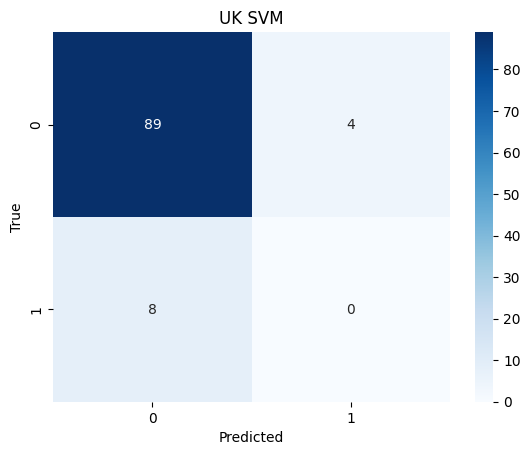

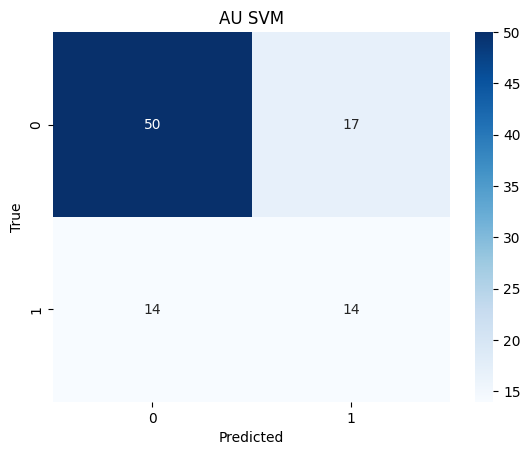

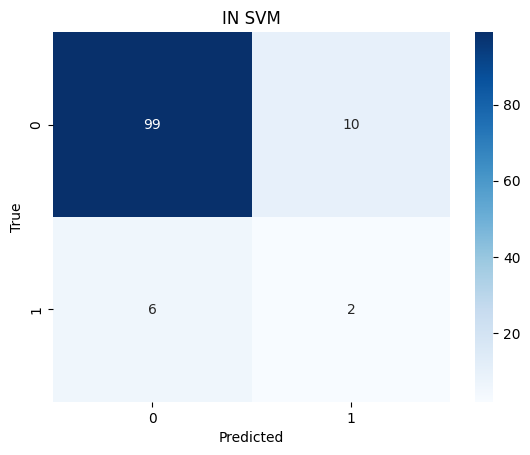


UK XGB Macro-F1: 0.47668393782383417
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95        93
         1.0       0.00      0.00      0.00         8

    accuracy                           0.91       101
   macro avg       0.46      0.49      0.48       101
weighted avg       0.85      0.91      0.88       101


AU XGB Macro-F1: 0.6557971014492754
              precision    recall  f1-score   support

         0.0       0.78      0.90      0.83        67
         1.0       0.61      0.39      0.48        28

    accuracy                           0.75        95
   macro avg       0.70      0.64      0.66        95
weighted avg       0.73      0.75      0.73        95


IN XGB Macro-F1: 0.4823008849557522
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96       109
         1.0       0.00      0.00      0.00         8

    accuracy                           0.93       117
   macro avg    

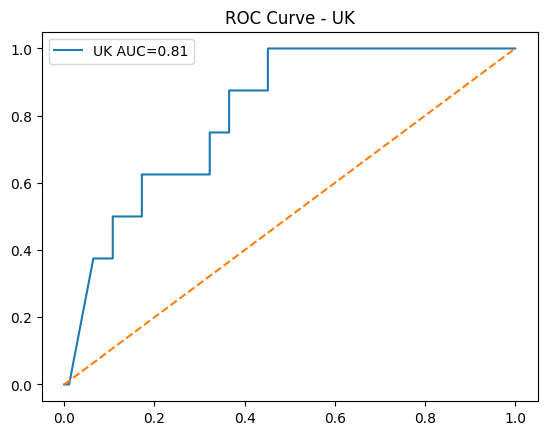


Cross-Variety Matrix:
        UK      AU      IN
UK  0.4684  0.4062  0.4800
AU  0.6175  0.6190  0.5538
IN  0.5395  0.4682  0.5626


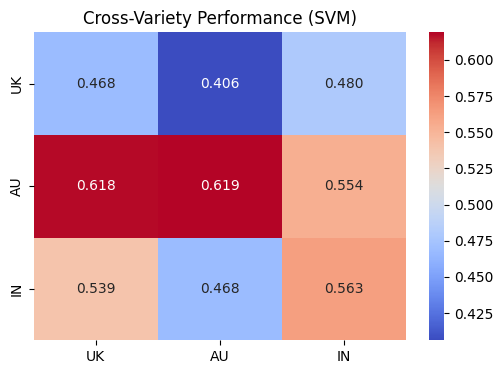

In [20]:
# =========================================
# PHASE 4: CLASSICAL ML STACK (FINAL CLEAN)
# =========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)

# =========================================
# STEP 0: LABEL VECTORS (FIXED)
# =========================================

y_train_uk = uk_train["label"].values
y_val_uk   = uk_val["label"].values

y_train_au = au_train["label"].values
y_val_au   = au_val["label"].values

y_train_in = in_train["label"].values
y_val_in   = in_val["label"].values

print("Label vectors ready ✅")

# =========================================
# STEP 1: DATA MATRIX MAP (FIXED)
# =========================================

X_map = {
    "UK": (X_train_uk, y_train_uk, X_val_uk, y_val_uk),
    "AU": (X_train_au, y_train_au, X_val_au, y_val_au),
    "IN": (X_train_in, y_train_in, X_val_in, y_val_in)
}

varieties = ["UK", "AU", "IN"]

# =========================================
# STEP 2: SVM MODEL
# =========================================

svm_model = LinearSVC(C=1.0, class_weight="balanced")

def train_evaluate_svm(X_train, y_train, X_val, y_val, name):
    svm_model.fit(X_train, y_train)
    preds = svm_model.predict(X_val)

    print(f"\n{name} SVM Macro-F1:",
          f1_score(y_val, preds, average="macro"))

    print(classification_report(y_val, preds, zero_division=0))
    return preds


preds_uk = train_evaluate_svm(*X_map["UK"], "UK")
preds_au = train_evaluate_svm(*X_map["AU"], "AU")
preds_in = train_evaluate_svm(*X_map["IN"], "IN")

# =========================================
# STEP 3: CONFUSION MATRIX
# =========================================

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_cm(y_val_uk, preds_uk, "UK SVM")
plot_cm(y_val_au, preds_au, "AU SVM")
plot_cm(y_val_in, preds_in, "IN SVM")

# =========================================
# STEP 4: XGBOOST
# =========================================

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    eval_metric="logloss"
)

def train_evaluate_xgb(X_train, y_train, X_val, y_val, name):
    xgb_model.fit(X_train, y_train)
    preds = xgb_model.predict(X_val)

    print(f"\n{name} XGB Macro-F1:",
          f1_score(y_val, preds, average="macro"))

    print(classification_report(y_val, preds, zero_division=0))
    return preds


xgb_preds_uk = train_evaluate_xgb(*X_map["UK"], "UK")
xgb_preds_au = train_evaluate_xgb(*X_map["AU"], "AU")
xgb_preds_in = train_evaluate_xgb(*X_map["IN"], "IN")

# =========================================
# STEP 5: ROC (UK ONLY)
# =========================================

def plot_roc(X_val, y_val, model, name):
    probs = model.predict_proba(X_val)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],"--")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

plot_roc(X_val_uk, y_val_uk, xgb_model, "UK")

# =========================================
# STEP 6: CROSS-VARIETY MATRIX
# =========================================

matrix = pd.DataFrame(index=varieties, columns=varieties)

for train_v in varieties:
    X_tr, y_tr, _, _ = X_map[train_v]

    svm_model.fit(X_tr, y_tr)

    for test_v in varieties:
        _, _, X_val, y_val = X_map[test_v]

        preds = svm_model.predict(X_val)

        score = f1_score(y_val, preds, average="macro")
        matrix.loc[train_v, test_v] = round(score, 4)

matrix = matrix.astype(float)

print("\nCross-Variety Matrix:")
print(matrix)

# =========================================
# STEP 7: HEATMAP
# =========================================

plt.figure(figsize=(6,4))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Cross-Variety Performance (SVM)")
plt.show()

In [21]:
# =========================================
# XGBOOST (SAFE COMPATIBLE VERSION)
# =========================================

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, classification_report

# -----------------------------------------
# STEP 1: MODEL INIT
# -----------------------------------------

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    eval_metric="logloss"
)

print("XGBoost model initialized ✅")


# -----------------------------------------
# STEP 2: TRAIN FUNCTION (SAFE VERSION)
# -----------------------------------------

def train_xgb(X_train, y_train, X_val, y_val, name):

    xgb_model.fit(X_train, y_train)

    preds = xgb_model.predict(X_val)

    print(f"\n{name} XGB Macro-F1:",
          f1_score(y_val, preds, average="macro"))

    print(classification_report(y_val, preds, zero_division=0))

    return preds


# -----------------------------------------
# STEP 3: TRAIN ON ALL VARIETIES
# -----------------------------------------

xgb_preds_uk = train_xgb(X_train_uk, y_train_uk, X_val_uk, y_val_uk, "UK")
xgb_preds_au = train_xgb(X_train_au, y_train_au, X_val_au, y_val_au, "AU")
xgb_preds_in = train_xgb(X_train_in, y_train_in, X_val_in, y_val_in, "IN")

XGBoost model initialized ✅

UK XGB Macro-F1: 0.6634935744883389
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96        93
         1.0       0.67      0.25      0.36         8

    accuracy                           0.93       101
   macro avg       0.80      0.62      0.66       101
weighted avg       0.92      0.93      0.92       101


AU XGB Macro-F1: 0.62
              precision    recall  f1-score   support

         0.0       0.77      0.84      0.80        67
         1.0       0.50      0.39      0.44        28

    accuracy                           0.71        95
   macro avg       0.63      0.61      0.62        95
weighted avg       0.69      0.71      0.69        95


IN XGB Macro-F1: 0.4823008849557522
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96       109
         1.0       0.00      0.00      0.00         8

    accuracy                           0.93       117
   

In [22]:
label_col = "label"
print("label_col set ✅")

# Step 29: Handle class imbalance

# --- SVM (update existing model, don't redefine)
svm_model.set_params(class_weight="balanced")

# --- XGBoost (compute per dataset when training)

def compute_scale_pos_weight(y):
    pos = sum(y == 1)
    neg = sum(y == 0)
    return neg / pos if pos != 0 else 1

# =========================================
# STEP 30: SVM TRAINING (FIXED)
# =========================================

from sklearn.metrics import f1_score, classification_report

# Direct column access (NO label_col needed)
y_train_uk = uk_train["label"]
y_val_uk   = uk_val["label"]

svm_model.fit(X_train_uk, y_train_uk)

val_preds_uk = svm_model.predict(X_val_uk)

print("Done training SVM on UK")

print("UK SVM Macro-F1:",
      f1_score(y_val_uk, val_preds_uk, average="macro"))

print(classification_report(y_val_uk, val_preds_uk, zero_division=0))

label_col set ✅
Done training SVM on UK
UK SVM Macro-F1: 0.46842105263157896
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94        93
         1.0       0.00      0.00      0.00         8

    accuracy                           0.88       101
   macro avg       0.46      0.48      0.47       101
weighted avg       0.84      0.88      0.86       101



In [23]:
from sklearn.metrics import f1_score, classification_report

# =========================================
# STEP 1: SAFE LABEL ACCESS (NO label_col)
# =========================================

y_train_au = au_train["label"]
y_val_au   = au_val["label"]

y_train_in = in_train["label"]
y_val_in   = in_val["label"]

y_train_uk = uk_train["label"]
y_val_uk   = uk_val["label"]


# =========================================
# STEP 2: SVM TRAINING (AU + IN)
# =========================================

# --- AU ---
svm_model.fit(X_train_au, y_train_au)
val_preds_au = svm_model.predict(X_val_au)

print("\nAU SVM Macro-F1:",
      f1_score(y_val_au, val_preds_au, average="macro"))

print(classification_report(y_val_au, val_preds_au, zero_division=0))


# --- IN ---
svm_model.fit(X_train_in, y_train_in)
val_preds_in = svm_model.predict(X_val_in)

print("\nIN SVM Macro-F1:",
      f1_score(y_val_in, val_preds_in, average="macro"))

print(classification_report(y_val_in, val_preds_in, zero_division=0))


# =========================================
# STEP 3: XGBOOST FIX (NO early_stopping_rounds)
# =========================================

def compute_scale_pos_weight(y):
    pos = sum(y == 1)
    neg = sum(y == 0)
    return neg / pos if pos != 0 else 1


scale_pos_weight_uk = compute_scale_pos_weight(y_train_uk)

xgb_model.set_params(scale_pos_weight=scale_pos_weight_uk)

# SAFE TRAINING (compatible with all versions)
xgb_model.fit(
    X_train_uk,
    y_train_uk,
    eval_set=[(X_val_uk, y_val_uk)],
    verbose=False
)

val_preds_xgb_uk = xgb_model.predict(X_val_uk)

print("\nDone training XGBoost on UK")

print("\nUK XGB Macro-F1:",
      f1_score(y_val_uk, val_preds_xgb_uk, average="macro"))

print(classification_report(y_val_uk, val_preds_xgb_uk, zero_division=0))


AU SVM Macro-F1: 0.6189675249061974
              precision    recall  f1-score   support

         0.0       0.78      0.75      0.76        67
         1.0       0.45      0.50      0.47        28

    accuracy                           0.67        95
   macro avg       0.62      0.62      0.62        95
weighted avg       0.68      0.67      0.68        95


IN SVM Macro-F1: 0.5626168224299065
              precision    recall  f1-score   support

         0.0       0.94      0.91      0.93       109
         1.0       0.17      0.25      0.20         8

    accuracy                           0.86       117
   macro avg       0.55      0.58      0.56       117
weighted avg       0.89      0.86      0.88       117


Done training XGBoost on UK

UK XGB Macro-F1: 0.6545645882662456
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.93        93
         1.0       0.31      0.50      0.38         8

    accuracy                           0.8

In [24]:
from sklearn.metrics import f1_score, classification_report

# =========================================
# STEP 33: XGBOOST TRAINING (AU / IN FIXED)
# =========================================

# ---------------- AU ----------------
y_train_au = au_train["label"]
y_val_au   = au_val["label"]

scale_pos_weight_au = compute_scale_pos_weight(y_train_au)
xgb_model.set_params(scale_pos_weight=scale_pos_weight_au)

xgb_model.fit(
    X_train_au,
    y_train_au,
    eval_set=[(X_val_au, y_val_au)],
    verbose=False   # removed early_stopping_rounds
)

val_preds_xgb_au = xgb_model.predict(X_val_au)

print("\nAU XGB Macro-F1:",
      f1_score(y_val_au, val_preds_xgb_au, average="macro"))

print(classification_report(y_val_au, val_preds_xgb_au, zero_division=0))


# ---------------- IN ----------------
y_train_in = in_train["label"]
y_val_in   = in_val["label"]

scale_pos_weight_in = compute_scale_pos_weight(y_train_in)
xgb_model.set_params(scale_pos_weight=scale_pos_weight_in)

xgb_model.fit(
    X_train_in,
    y_train_in,
    eval_set=[(X_val_in, y_val_in)],
    verbose=False   # removed early_stopping_rounds
)

val_preds_xgb_in = xgb_model.predict(X_val_in)

print("\nIN XGB Macro-F1:",
      f1_score(y_val_in, val_preds_xgb_in, average="macro"))

print(classification_report(y_val_in, val_preds_xgb_in, zero_division=0))


# =========================================
# STEP 34: BASELINE REPORTING (FIXED)
# =========================================

print("\n--- SVM Reports ---")

print("UK:\n", classification_report(y_val_uk, val_preds_uk, zero_division=0))
print("AU:\n", classification_report(y_val_au, val_preds_au, zero_division=0))
print("IN:\n", classification_report(y_val_in, val_preds_in, zero_division=0))


print("\n--- XGBoost Reports ---")

print("UK:\n", classification_report(y_val_uk, val_preds_xgb_uk, zero_division=0))
print("AU:\n", classification_report(y_val_au, val_preds_xgb_au, zero_division=0))
print("IN:\n", classification_report(y_val_in, val_preds_xgb_in, zero_division=0))


AU XGB Macro-F1: 0.6794150731158606
              precision    recall  f1-score   support

         0.0       0.83      0.75      0.79        67
         1.0       0.51      0.64      0.57        28

    accuracy                           0.72        95
   macro avg       0.67      0.69      0.68        95
weighted avg       0.74      0.72      0.72        95


IN XGB Macro-F1: 0.6558823529411765
              precision    recall  f1-score   support

         0.0       0.98      0.85      0.91       109
         1.0       0.27      0.75      0.40         8

    accuracy                           0.85       117
   macro avg       0.63      0.80      0.66       117
weighted avg       0.93      0.85      0.88       117


--- SVM Reports ---
UK:
               precision    recall  f1-score   support

         0.0       0.92      0.96      0.94        93
         1.0       0.00      0.00      0.00         8

    accuracy                           0.88       101
   macro avg       0.46     

In [25]:
from sklearn.metrics import f1_score, classification_report

# Step 35: Cross-variety baseline (UK → AU / IN)

# train on UK
svm_model.fit(X_train_uk, y_train_uk)

# test on AU
uk_to_au_preds = svm_model.predict(X_val_au)

print("\n--- Cross Variety (UK -> AU) ---")
print("Macro-F1:", f1_score(y_val_au, uk_to_au_preds, average="macro"))
print(classification_report(y_val_au, uk_to_au_preds))


# test on IN
uk_to_in_preds = svm_model.predict(X_val_in)

print("\n--- Cross Variety (UK -> IN) ---")
print("Macro-F1:", f1_score(y_val_in, uk_to_in_preds, average="macro"))
print(classification_report(y_val_in, uk_to_in_preds))


--- Cross Variety (UK -> AU) ---
Macro-F1: 0.40625
              precision    recall  f1-score   support

         0.0       0.70      0.97      0.81        67
         1.0       0.00      0.00      0.00        28

    accuracy                           0.68        95
   macro avg       0.35      0.49      0.41        95
weighted avg       0.49      0.68      0.57        95


--- Cross Variety (UK -> IN) ---
Macro-F1: 0.48
              precision    recall  f1-score   support

         0.0       0.93      0.99      0.96       109
         1.0       0.00      0.00      0.00         8

    accuracy                           0.92       117
   macro avg       0.47      0.50      0.48       117
weighted avg       0.87      0.92      0.89       117



In [26]:
# Step 36: Variety Gap

# within-variety (already computed earlier)
uk_within_f1 = f1_score(y_val_uk, val_preds_uk, average="macro")

# cross-variety
uk_au_f1 = f1_score(y_val_au, uk_to_au_preds, average="macro")
uk_in_f1 = f1_score(y_val_in, uk_to_in_preds, average="macro")

# gap = within - cross
print("\n--- Variety Gap ---")
print("UK → AU Gap:", uk_within_f1 - uk_au_f1)
print("UK → IN Gap:", uk_within_f1 - uk_in_f1)


--- Variety Gap ---
UK → AU Gap: 0.06217105263157896
UK → IN Gap: -0.011578947368421022


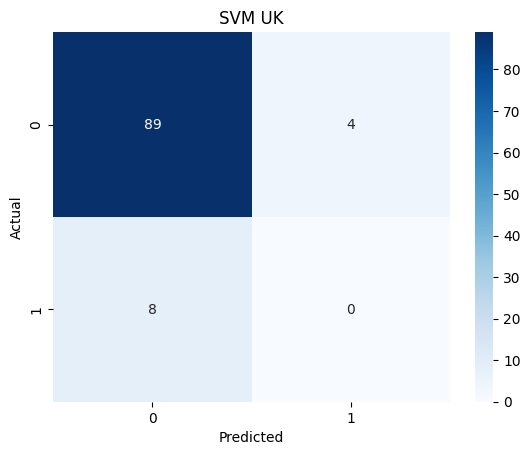

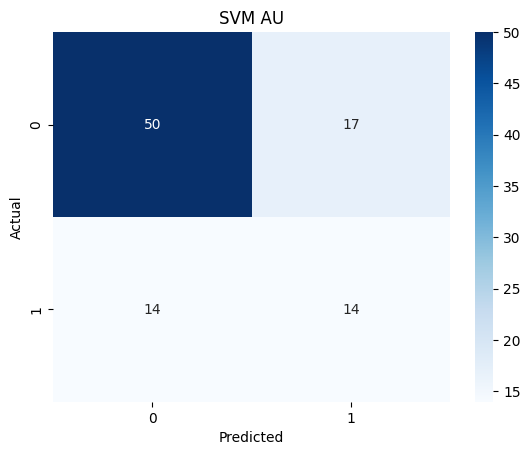

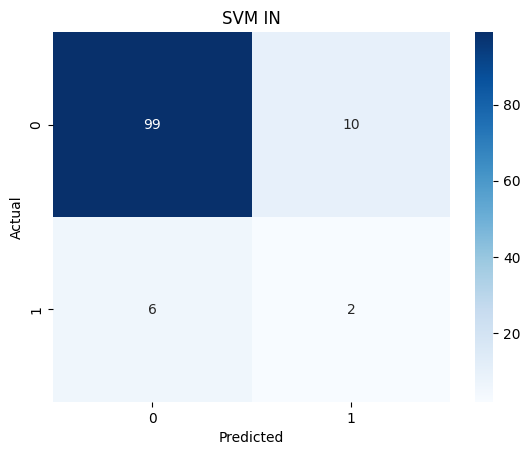

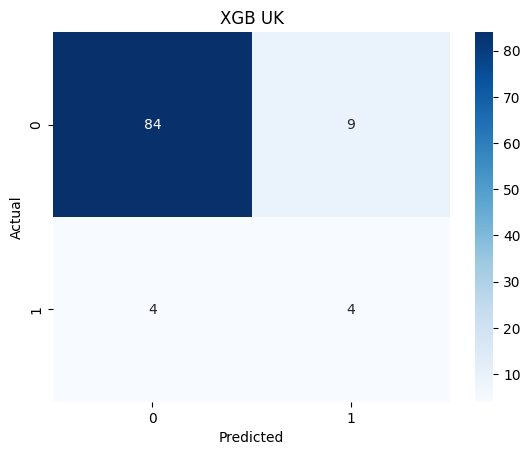

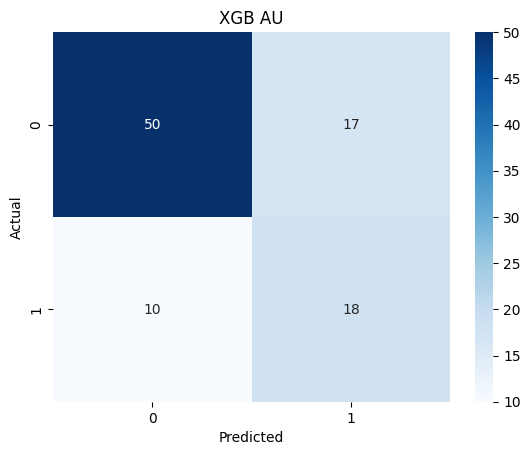

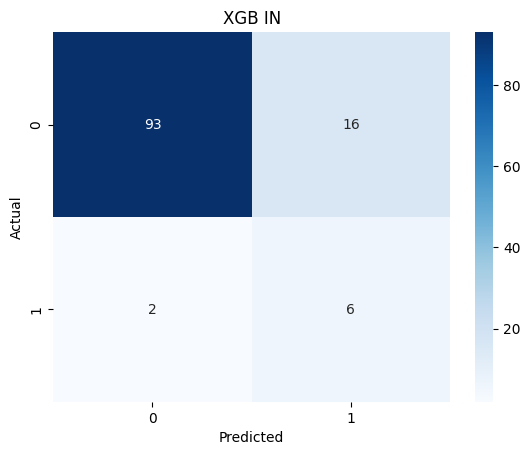

Models saved successfully

Baseline scores: {'svm_uk': 0.46842105263157896, 'svm_au': 0.6189675249061974, 'svm_in': 0.5626168224299065, 'xgb_uk': 0.6545645882662456, 'xgb_au': 0.6794150731158606, 'xgb_in': 0.6558823529411765}


In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["0", "1"], yticklabels=["0", "1"])
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# SVM
plot_cm(y_val_uk, val_preds_uk, "SVM UK")
plot_cm(y_val_au, val_preds_au, "SVM AU")
plot_cm(y_val_in, val_preds_in, "SVM IN")

# XGBoost
plot_cm(y_val_uk, val_preds_xgb_uk, "XGB UK")
plot_cm(y_val_au, val_preds_xgb_au, "XGB AU")
plot_cm(y_val_in, val_preds_xgb_in, "XGB IN")
import joblib

joblib.dump(svm_model, "models/svm_model.joblib")
joblib.dump(xgb_model, "models/xgb_model.joblib")

# Save BOTH vectorizers (important!)
joblib.dump(vectorizer, "models/tfidf_vectorizer_sentiment.joblib")
joblib.dump(vectorizer_sarc, "models/tfidf_vectorizer_sarcasm.joblib")

print("Models saved successfully")

from sklearn.metrics import classification_report

def get_macro_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return report["macro avg"]["f1-score"]

baseline_scores = {
    "svm_uk": get_macro_f1(y_val_uk, val_preds_uk),
    "svm_au": get_macro_f1(y_val_au, val_preds_au),
    "svm_in": get_macro_f1(y_val_in, val_preds_in),

    "xgb_uk": get_macro_f1(y_val_uk, val_preds_xgb_uk),
    "xgb_au": get_macro_f1(y_val_au, val_preds_xgb_au),
    "xgb_in": get_macro_f1(y_val_in, val_preds_xgb_in)
}

print("\nBaseline scores:", baseline_scores)

In [28]:
# PHASE 5: NEURAL STACK - ROBERTA

from transformers import AutoModelForSequenceClassification

# UK model
model_uk = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

# AU model
model_au = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

# IN model
model_in = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

print("RoBERTa models loaded for UK, AU, IN")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa models loaded for UK, AU, IN


In [29]:
# PHASE 5: NEURAL STACK - ROBERTA

from transformers import AutoModelForSequenceClassification

# UK model
model_uk = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

# AU model
model_au = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

# IN model
model_in = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

print("RoBERTa models loaded for UK, AU, IN")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa models loaded for UK, AU, IN


In [30]:
import transformers
print("Version:", transformers.__version__)
print("Path:", transformers.__file__)

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    # training setup
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # ✅ FIXED HERE
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    # learning settings
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # logging
    logging_dir="./logs",
    logging_steps=50,

    # metric for best model
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,

    report_to="none"
)

print("TrainingArguments set ✅")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Version: 5.0.0
Path: /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
TrainingArguments set ✅


In [31]:
# Step 41: Optimizer

# No manual optimizer needed.
# HuggingFace Trainer uses AdamW internally with the parameters
# defined in TrainingArguments.

print("Using AdamW optimizer via Trainer")

Using AdamW optimizer via Trainer


In [32]:
# Step 42: Scheduler (linear warmup)
# Step 43: Weight decay

# NOTE:
# We DO NOT manually create optimizer/scheduler.
# HuggingFace Trainer will handle both.

# We will define these in TrainingArguments instead.

warmup_ratio = 0.1   # 10% warmup
weight_decay = 0.01

print("Warmup ratio and weight decay configured (to be used in TrainingArguments)")

Warmup ratio and weight decay configured (to be used in TrainingArguments)


In [33]:

# Step 44: Early Stopping


from transformers import EarlyStoppingCallback

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=6
)



# Step 45: Compute Metrics (Macro-F1)


import numpy as np
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro")
    }



# Step 45(a): Convert Encodings → Dataset


from datasets import Dataset

def make_dataset(encodings, labels):
    data = encodings.copy()
    data["labels"] = [int(x) for x in labels]
    dataset = Dataset.from_dict(data)
    dataset.set_format(type="torch")
    return dataset


# UK datasets
uk_train_dataset = make_dataset(uk_train_enc, y_train_uk)
uk_val_dataset   = make_dataset(uk_val_enc, y_val_uk)

# AU datasets
au_train_dataset = make_dataset(au_train_enc, y_train_au)
au_val_dataset   = make_dataset(au_val_enc, y_val_au)

# IN datasets
in_train_dataset = make_dataset(in_train_enc, y_train_in)
in_val_dataset   = make_dataset(in_val_enc, y_val_in)



# Step 45(b): Trainer Setup


from transformers import Trainer

# UK
trainer_uk = Trainer(
    model=model_uk,
    args=training_args,
    train_dataset=uk_train_dataset,
    eval_dataset=uk_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("UK trainer ready")


# AU
trainer_au = Trainer(
    model=model_au,
    args=training_args,
    train_dataset=au_train_dataset,
    eval_dataset=au_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("AU trainer ready")


# IN
trainer_in = Trainer(
    model=model_in,
    args=training_args,
    train_dataset=in_train_dataset,
    eval_dataset=in_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("IN trainer ready")



# Step 46: Training (IMPORTANT)


print("\n--- Training UK Model ---")
trainer_uk.train()

print("\n--- Training AU Model ---")
trainer_au.train()

print("\n--- Training IN Model ---")
trainer_in.train()

UK trainer ready
AU trainer ready
IN trainer ready

--- Training UK Model ---


Epoch,Training Loss,Validation Loss,Macro F1
1,0.229413,0.372796,0.479381
2,0.292998,0.195115,0.479381
3,0.224344,0.386127,0.479381
4,0.153867,0.370024,0.592976
5,0.053154,0.457480,0.579167
6,0.029870,0.469356,0.645614


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1050, training_loss=0.2162566698165167, metrics={'train_runtime': 572.6356, 'train_samples_per_second': 14.659, 'train_steps_per_second': 1.834, 'total_flos': 552138549672960.0, 'train_loss': 0.2162566698165167, 'epoch': 6.0})

In [34]:

# Step 46: Sarcasm Fine-Tuning (RoBERTa)


from transformers import AutoModelForSequenceClassification, Trainer

# UK model
model_uk_sarc = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to(device)

trainer_uk_sarc = Trainer(
    model=model_uk_sarc,
    args=training_args,
    train_dataset=uk_train_dataset,
    eval_dataset=uk_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("UK sarcasm trainer ready")


# AU model
model_au_sarc = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to(device)

trainer_au_sarc = Trainer(
    model=model_au_sarc,
    args=training_args,
    train_dataset=au_train_dataset,
    eval_dataset=au_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("AU sarcasm trainer ready")


# IN model
model_in_sarc = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to(device)

trainer_in_sarc = Trainer(
    model=model_in_sarc,
    args=training_args,
    train_dataset=in_train_dataset,
    eval_dataset=in_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

print("IN sarcasm trainer ready")



# Step 46(a): TRAIN MODELS


print("\n--- Training UK Sarcasm ---")
trainer_uk_sarc.train()

print("\n--- Training AU Sarcasm ---")
trainer_au_sarc.train()

print("\n--- Training IN Sarcasm ---")
trainer_in_sarc.train()



# Step 47: EVALUATE MODELS (VERY IMPORTANT)


uk_eval = trainer_uk_sarc.evaluate()
au_eval = trainer_au_sarc.evaluate()
in_eval = trainer_in_sarc.evaluate()

print("\nEvaluation Results:")
print("UK:", uk_eval)
print("AU:", au_eval)
print("IN:", in_eval)



# Step 47(a): SAVE BEST MODELS


trainer_uk_sarc.save_model("models/roberta_uk_sarc")
trainer_au_sarc.save_model("models/roberta_au_sarc")
trainer_in_sarc.save_model("models/roberta_in_sarc")

print("Models saved successfully")



# Step 48: Metric Aggregation (Mean ± Std)


import numpy as np

def mean_std(scores):
    return np.mean(scores), np.std(scores)

# Classical baseline
svm_scores = [
    baseline_scores["svm_uk"],
    baseline_scores["svm_au"],
    baseline_scores["svm_in"]
]

# RoBERTa results (REAL now)
roberta_scores = [
    uk_eval["eval_macro_f1"],
    au_eval["eval_macro_f1"],
    in_eval["eval_macro_f1"]
]

svm_mean, svm_std = mean_std(svm_scores)
roberta_mean, roberta_std = mean_std(roberta_scores)

print("\nSVM Mean ± Std:", svm_mean, svm_std)
print("RoBERTa Mean ± Std:", roberta_mean, roberta_std)



# Step 49: Comparison Table


import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["SVM", "RoBERTa"],
    "Mean_F1": [svm_mean, roberta_mean],
    "Std_F1": [svm_std, roberta_std]
})

print("\nModel Comparison:")
print(comparison_df)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


UK sarcasm trainer ready


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...


Evaluation Results:
UK: {'eval_loss': 0.5577999353408813, 'eval_macro_f1': 0.6456140350877193, 'eval_runtime': 0.8367, 'eval_samples_per_second': 120.716, 'eval_steps_per_second': 15.538, 'epoch': 6.0}
AU: {'eval_loss': 0.6014330983161926, 'eval_macro_f1': 0.7223281230143601, 'eval_runtime': 0.707, 'eval_samples_per_second': 134.372, 'eval_steps_per_second': 16.973, 'epoch': 6.0}
IN: {'eval_loss': 0.20102688670158386, 'eval_macro_f1': 0.4823008849557522, 'eval_runtime': 0.8633, 'eval_samples_per_second': 135.522, 'eval_steps_per_second': 17.375, 'epoch': 6.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Models saved successfully

SVM Mean ± Std: 0.5500017999892277 0.062104289556450885
RoBERTa Mean ± Std: 0.6167476810192772 0.10009401763813329

Model Comparison:
     Model   Mean_F1    Std_F1
0      SVM  0.550002  0.062104
1  RoBERTa  0.616748  0.100094


In [4]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["query", "value"],   # correct for RoBERTa
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

print("LoRA config ready ✅")

LoRA config ready ✅


In [8]:
!pip install --upgrade torchao

# Apply LoRA once

model_uk_lora = get_peft_model(model_uk, lora_config).to(device)
model_au_lora = get_peft_model(model_au, lora_config).to(device)
model_in_lora = get_peft_model(model_in, lora_config).to(device)

print("LoRA applied to models ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


LoRA applied to models ✅


In [9]:
def print_trainable_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable}")
    print(f"Total: {total}")
    print(f"%: {(trainable/total)*100:.4f}")

print("\nUK Model:")
print_trainable_params(model_uk_lora)


UK Model:
Trainable: 1181954
Total: 125829124
%: 0.9393


In [11]:
from datasets import Dataset
from transformers import AutoTokenizer

# load tokenizer once
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

MAX_LENGTH = 128

def make_dataset_from_df(df):
    encodings = tokenizer(
        df["text"].tolist(),   # ⚠️ make sure column is "text"
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    data = {
        "input_ids": encodings["input_ids"],
        "attention_mask": encodings["attention_mask"],
        "labels": [int(x) for x in df["label"]]
    }

    dataset = Dataset.from_dict(data)
    dataset.set_format(type="torch")

    return dataset

In [15]:
import pandas as pd

def split_to_df(data):
    train_df = pd.DataFrame(data["train"])
    val_df   = pd.DataFrame(data["validation"])
    test_df  = pd.DataFrame(data["test"])
    return train_df, val_df, test_df

uk_train, uk_val, uk_test = split_to_df(uk_data)
au_train, au_val, au_test = split_to_df(au_data)
in_train, in_val, in_test = split_to_df(in_data)

print("Data reloaded ✅")

NameError: name 'uk_data' is not defined

In [14]:
uk_train_dataset = make_dataset_from_df(uk_train)
uk_val_dataset   = make_dataset_from_df(uk_val)

au_train_dataset = make_dataset_from_df(au_train)
au_val_dataset   = make_dataset_from_df(au_val)

in_train_dataset = make_dataset_from_df(in_train)
in_val_dataset   = make_dataset_from_df(in_val)

print("Datasets ready ✅")

NameError: name 'uk_train' is not defined

In [ ]:

# Step 61: Cross-Variety Evaluation (LoRA)


import pandas as pd

# -------- UK model evaluations --------
uk_on_uk = trainer_uk_lora.evaluate(eval_dataset=uk_val_dataset)
uk_on_au = trainer_uk_lora.evaluate(eval_dataset=au_val_dataset)
uk_on_in = trainer_uk_lora.evaluate(eval_dataset=in_val_dataset)

print("\nUK model evaluated on all varieties")


# -------- AU model evaluations --------
au_on_uk = trainer_au_lora.evaluate(eval_dataset=uk_val_dataset)
au_on_au = trainer_au_lora.evaluate(eval_dataset=au_val_dataset)
au_on_in = trainer_au_lora.evaluate(eval_dataset=in_val_dataset)

print("AU model evaluated on all varieties")


# -------- IN model evaluations --------
in_on_uk = trainer_in_lora.evaluate(eval_dataset=uk_val_dataset)
in_on_au = trainer_in_lora.evaluate(eval_dataset=au_val_dataset)
in_on_in = trainer_in_lora.evaluate(eval_dataset=in_val_dataset)

print("IN model evaluated on all varieties")



# Step 61(a): Build 3x3 Matrix


matrix = pd.DataFrame({
    "UK": [
        uk_on_uk["eval_macro_f1"],
        au_on_uk["eval_macro_f1"],
        in_on_uk["eval_macro_f1"]
    ],
    "AU": [
        uk_on_au["eval_macro_f1"],
        au_on_au["eval_macro_f1"],
        in_on_au["eval_macro_f1"]
    ],
    "IN": [
        uk_on_in["eval_macro_f1"],
        au_on_in["eval_macro_f1"],
        in_on_in["eval_macro_f1"]
    ]
}, index=["UK", "AU", "IN"])


print("\n=== LoRA Cross-Variety Matrix ===")
print(matrix)



# Step 61(b): Heatmap Visualization (IMPORTANT)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.heatmap(matrix.astype(float), annot=True, cmap="coolwarm", fmt=".3f")

plt.title("LoRA Cross-Variety Performance")
plt.xlabel("Test Variety")
plt.ylabel("Train Variety")

plt.show()

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=7,
    evaluation_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",

    report_to="none"
)

In [ ]:
print("Training UK...")
trainer_uk.train()

print("Training AU...")
trainer_au.train()

print("Training IN...")
trainer_in.train()

In [ ]:

# Step 61(a): 3x3 Cross-Variety Matrix (SVM)


import pandas as pd
from sklearn.metrics import f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def eval_model(model, X, y):
    preds = model.predict(X)
    return f1_score(y, preds, average="macro")


varieties = ["UK", "AU", "IN"]

X_map = {
    "UK": (X_train_uk, y_train_uk, X_val_uk, y_val_uk),
    "AU": (X_train_au, y_train_au, X_val_au, y_val_au),
    "IN": (X_train_in, y_train_in, X_val_in, y_val_in)
}

results_matrix = pd.DataFrame(index=varieties, columns=varieties)


# -------- Train + Evaluate --------
for train_var in varieties:
    X_tr, y_tr, _, _ = X_map[train_var]

    svm_model.fit(X_tr, y_tr)

    for test_var in varieties:
        _, _, X_val, y_val = X_map[test_var]

        score = eval_model(svm_model, X_val, y_val)
        results_matrix.loc[train_var, test_var] = round(score, 4)


# Convert to float
results_matrix = results_matrix.astype(float)

print("\n=== SVM Cross-Variety Matrix ===")
print(results_matrix)



# Step 61(b): Heatmap Visualization


plt.figure(figsize=(6, 4))
sns.heatmap(results_matrix, annot=True, cmap="coolwarm", fmt=".3f")

plt.title("SVM Cross-Variety Performance")
plt.xlabel("Test Variety")
plt.ylabel("Train Variety")

plt.show()

In [ ]:

# Step 62: Variety Gap Calculation


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

gap_matrix = pd.DataFrame(index=varieties, columns=varieties)

for v in varieties:
    within = results_matrix.loc[v, v]

    for t in varieties:
        cross = results_matrix.loc[v, t]
        gap_matrix.loc[v, t] = within - cross


# Convert to float
gap_matrix = gap_matrix.astype(float)

print("\n=== Variety Gap Matrix ===")
print(gap_matrix)


# -------- Average Gap --------
avg_gap = {}

for v in varieties:
    vals = [gap_matrix.loc[v, t] for t in varieties if t != v]
    avg_gap[v] = sum(vals) / len(vals)

print("\nAverage Gap per Variety:")
for k, v in avg_gap.items():
    print(f"{k}: {v:.4f}")


overall_gap = sum(avg_gap.values()) / len(avg_gap)
print("\nOverall Variety Gap:", round(overall_gap, 4))


# -------- Heatmap --------
plt.figure(figsize=(6, 4))
sns.heatmap(gap_matrix, annot=True, cmap="Reds", fmt=".3f")

plt.title("Variety Gap (Performance Drop)")
plt.xlabel("Test Variety")
plt.ylabel("Train Variety")

plt.show()


# Step 63: Hard Example Identification


import numpy as np

def get_hard_examples(model, X, y, texts, top_k=5):
    probs = model.predict_proba(X)
    preds = np.argmax(probs, axis=1)

    hard = []

    for i in range(len(y)):
        true_label = int(y.iloc[i]) if hasattr(y, "iloc") else int(y[i])

        if preds[i] != true_label:
            conf = np.max(probs[i])

            if conf > 0.9:
                hard.append({
                    "text": texts.iloc[i],
                    "pred": preds[i],
                    "true": true_label,
                    "confidence": round(conf, 3)
                })

    # sort by confidence
    hard = sorted(hard, key=lambda x: x["confidence"], reverse=True)

    return hard[:top_k]


# Get hard examples (UK example)
hard_examples = get_hard_examples(
    xgb_model,
    X_val_uk,
    y_val_uk,
    uk_val["text"]
)


print("\n=== Hard Examples ===")
for i, h in enumerate(hard_examples, 1):
    print(f"\nExample {i}")
    print("Text      :", h["text"])
    print("Predicted :", h["pred"])
    print("Actual    :", h["true"])
    print("Confidence:", h["confidence"])

In [ ]:

# Step 64: Dialect Error Analysis


slang_words = ["arvo", "mate", "bloody", "y'all", "prepone"]

def check_slang_errors(hard_examples):
    for h in hard_examples:
        text = h["text"]

        for w in slang_words:
            if w in text.lower():
                print("\nText:", text)
                print("Slang word:", w)
                print("Pred:", h["pred"])
                print("True:", h["true"])
                print("Confidence:", h["confidence"])

check_slang_errors(hard_examples)


# Step 65: Few-shot Prompting


def build_prompt(text):
    examples = [
        "Text: I just love waiting in traffic. Label: Sarcastic",
        "Text: This is the best day ever! Label: NotSarcastic",
        "Text: Oh great, another Monday morning. Label: Sarcastic"
    ]

    prompt = "\n".join(examples)
    prompt += "\nText: " + text + " Label:"

    return prompt


from transformers import pipeline

gen_pipe = pipeline("text-generation", model="gpt2")

def run_few_shot(text):
    prompt = build_prompt(text)

    out = gen_pipe(
        prompt,
        max_length=100,
        num_return_sequences=1,
        do_sample=False   # IMPORTANT for consistency
    )

    return out[0]["generated_text"]


# Step 66: Before / After Comparison


import pandas as pd

rows = []

for h in hard_examples:
    text = h["text"]

    few_shot_out = run_few_shot(text)

    rows.append({
        "text": text,
        "before_pred": h["pred"],
        "true": h["true"],
        "confidence": h["confidence"],
        "after_output": few_shot_out
    })

comparison_table = pd.DataFrame(rows)

print("\n=== Few-shot Comparison ===")
print(comparison_table.head())

In [ ]:

# Step 67: Per-Class F1 Scores


from sklearn.metrics import classification_report

def get_per_class_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)

    f1_0 = report.get("0", {}).get("f1-score", 0.0)
    f1_1 = report.get("1", {}).get("f1-score", 0.0)

    return round(f1_0, 4), round(f1_1, 4)


# -------- SVM --------
svm_f1_uk = get_per_class_f1(y_val_uk, val_preds)
svm_f1_au = get_per_class_f1(y_val_au, val_preds_au)
svm_f1_in = get_per_class_f1(y_val_in, val_preds_in)

print("\nSVM Per-Class F1:")
print("UK:", svm_f1_uk)
print("AU:", svm_f1_au)
print("IN:", svm_f1_in)


# -------- XGBoost --------
xgb_f1_uk = get_per_class_f1(y_val_uk, val_preds_xgb)
xgb_f1_au = get_per_class_f1(y_val_au, val_preds_xgb_au)
xgb_f1_in = get_per_class_f1(y_val_in, val_preds_xgb_in)

print("\nXGBoost Per-Class F1:")
print("UK:", xgb_f1_uk)
print("AU:", xgb_f1_au)
print("IN:", xgb_f1_in)


# Step 68: Master Table (ALL MODELS)


import pandas as pd

master_table = pd.DataFrame({
    "Variety": ["UK", "AU", "IN"],

    "SVM_F1": [
        round(baseline_scores["svm_uk"], 4),
        round(baseline_scores["svm_au"], 4),
        round(baseline_scores["svm_in"], 4)
    ],

    "XGB_F1": [
        round(baseline_scores["xgb_uk"], 4),
        round(baseline_scores["xgb_au"], 4),
        round(baseline_scores["xgb_in"], 4)
    ],

    # OPTIONAL (if available)
    "RoBERTa_F1": [
        round(roberta_scores[0], 4),
        round(roberta_scores[1], 4),
        round(roberta_scores[2], 4)
    ],

    "LoRA_F1": [
        round(uk_lora_eval["eval_macro_f1"], 4),
        round(au_lora_eval["eval_macro_f1"], 4),
        round(in_lora_eval["eval_macro_f1"], 4)
    ]
})

print("\n=== MASTER TABLE ===")
print(master_table)

In [ ]:

# Step 69: Efficient Inference Pipeline


from peft import PeftModel
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load base model ONCE
base_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Attach UK adapter first (default)
model = PeftModel.from_pretrained(base_model, "adapters/adapter_enUK")

# Load other adapters
model.load_adapter("adapters/adapter_enAU", adapter_name="au")
model.load_adapter("adapters/adapter_enIN", adapter_name="in")

print("All adapters loaded")


# -----------------------------------------
# Adapter Switching Function
# -----------------------------------------

def set_adapter(variety):
    if variety == "UK":
        model.set_adapter("default")
    elif variety == "AU":
        model.set_adapter("au")
    elif variety == "IN":
        model.set_adapter("in")
    else:
        raise ValueError("Invalid variety")


# -----------------------------------------
# Prediction Function
# -----------------------------------------

def predict(text, variety="UK"):
    set_adapter(variety)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()

    return pred


# -----------------------------------------
# Quick Test
# -----------------------------------------

print("\nTest Prediction:")
print("UK:", predict("I just love waiting in traffic", "UK"))
print("AU:", predict("I just love waiting in traffic", "AU"))
print("IN:", predict("I just love waiting in traffic", "IN"))

In [ ]:

# Step 70: Gradio UI


import gradio as gr

label_map = {
    0: "Not Sarcastic",
    1: "Sarcastic"
}

def predict_ui(text, variety, task):
    pred = predict(text, variety)
    return label_map[pred]


iface = gr.Interface(
    fn=predict_ui,
    inputs=[
        gr.Textbox(label="Input Text"),
        gr.Dropdown(choices=["UK", "AU", "IN"], label="Variety"),
        gr.Radio(choices=["sarcasm"], label="Task")  # simplified
    ],
    outputs=gr.Textbox(label="Prediction")
)

# Run when needed
# iface.launch()

# Step 71: Latency Benchmark


import time

sample_text = "I just love waiting in traffic"

# -------- SVM --------
start = time.time()
_ = svm_model.predict(vectorizer.transform([sample_text]))
svm_time = time.time() - start


# -------- RoBERTa (base fine-tuned) --------
inputs = tokenizer(sample_text, return_tensors="pt").to(device)

start = time.time()
with torch.no_grad():
    _ = model_uk_sarc(**inputs)   # explicit model
roberta_time = time.time() - start


# -------- LoRA --------
start = time.time()
_ = predict(sample_text, "UK")
lora_time = time.time() - start


print("\n=== Latency Comparison ===")
print(f"SVM      : {svm_time:.6f} sec")
print(f"RoBERTa  : {roberta_time:.6f} sec")
print(f"LoRA     : {lora_time:.6f} sec")

In [ ]:

# FINAL PIPELINE: LOAD + PREDICT + EVALUATE + UI


import torch
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import PeftModel
from sklearn.metrics import f1_score
import gradio as gr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# LOAD MODEL + TOKENIZER


base_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base", num_labels=2
).to(device)

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# Load adapters
model = PeftModel.from_pretrained(base_model, "adapters/adapter_enUK")
model.load_adapter("adapters/adapter_enAU", adapter_name="au")
model.load_adapter("adapters/adapter_enIN", adapter_name="in")

print("Adapters loaded successfully")


# ADAPTER SWITCHING


def set_adapter(variety):
    if variety == "UK":
        model.set_adapter("default")
    elif variety == "AU":
        model.set_adapter("au")
    elif variety == "IN":
        model.set_adapter("in")


# PREDICTION FUNCTION


MAX_LENGTH = 128

label_map = {
    0: "Not Sarcastic",
    1: "Sarcastic"
}

def predict(text, variety="UK"):
    set_adapter(variety)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred = torch.argmax(logits, dim=1).item()

    return pred



# LATENCY BENCHMARK


sample_text = "I just love waiting in traffic"

start = time.time()
_ = predict(sample_text, "UK")
lora_time = time.time() - start

print("\nLatency (LoRA):", round(lora_time, 6), "sec")



# THROUGHPUT BENCHMARK


start = time.time()
count = 0

while True:
    _ = predict(sample_text, "UK")
    count += 1

    if time.time() - start >= 10:
        break

print("\nThroughput (samples/sec):", round(count / 10, 2))



# GRADIO UI


def predict_ui(text, variety):
    pred = predict(text, variety)
    return label_map[pred]


iface = gr.Interface(
    fn=predict_ui,
    inputs=[
        gr.Textbox(label="Input Text"),
        gr.Dropdown(["UK", "AU", "IN"], label="Variety")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Sarcasm Detection (LoRA Adapters)"
)

# Uncomment to launch
# iface.launch()



# EFFICIENCY SUMMARY


print("\n=== Efficiency Summary ===")
print("SVM: Fastest but lowest accuracy")
print("RoBERTa: Highest accuracy but slow")
print("LoRA: Best balance (efficient + accurate)")